In [9]:
# Cell 0: Cài đặt nhanh các thư viện cần thiết cho quá trình train/evaluate model.
!pip install -q --upgrade pip
!pip install -q numpy pandas matplotlib seaborn scikit-learn optuna xgboost catboost torch

# OULAD Modeling - XGBoost + CatBoost + Tabular DL + Stacking

Notebook huan luyen 3 base models co Optuna tuning:
- XGBoost
- CatBoost
- Tabular Deep Learning (PyTorch MLP)

Sau do xay dung Stacking Ensemble (OOF) de tranh data leakage.

In [10]:
# Cell 2: Import thư viện, khai báo seed/đường dẫn, và nạp dữ liệu train-test đã FE.
import os
import json
import time
import copy
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print('Imports OK')

Imports OK


In [11]:
# =========================
# Cell 3: Thiết lập hyperparameter chung, seed, tên nhãn và đường dẫn lưu model.
# Cấu hình
# =========================
RANDOM_SEED = 42
OPTUNA_TRIALS = 50
N_FOLDS = 5
VAL_SIZE = 0.2
NUM_CLASSES = 4

LABEL_MAP = {0: 'Pass', 1: 'Fail', 2: 'Withdrawn', 3: 'Distinction'}

DATA_PATH = '/content/drive/MyDrive/Dataset/'

SAVE_DIR = './saved_models_xgb_cat_tabdl_stacking'
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f'DATA_PATH: {DATA_PATH}')
print(f'DEVICE: {DEVICE}')
print(f'OPTUNA_TRIALS: {OPTUNA_TRIALS}')

DATA_PATH: /content/drive/MyDrive/Dataset/
DEVICE: cuda
OPTUNA_TRIALS: 50


In [12]:
# =========================
# Cell 4: Đọc dữ liệu scaled, chọn feature, tạo X/y train-test và tập validation nội bộ.
# Nạp dữ liệu
# =========================
start_time = time.time()

# Đọc 2 tập đã scale từ notebook feature engineering.
df_train_scaled = pd.read_csv(os.path.join(DATA_PATH, 'df_train_scaled.csv'))
df_test_scaled = pd.read_csv(os.path.join(DATA_PATH, 'df_test_scaled.csv'))

feature_json = os.path.join(DATA_PATH, 'feature_cols.json')
if os.path.exists(feature_json):
    with open(feature_json, 'r') as f:
        feature_cols = json.load(f)
    feature_cols = [c for c in feature_cols if c != 'target']
else:
    exclude = {'target'}
    feature_cols = [c for c in df_train_scaled.columns if c not in exclude]

X_train = df_train_scaled[feature_cols].values.astype(np.float32)
y_train = df_train_scaled['target'].values.astype(int)
X_test = df_test_scaled[feature_cols].values.astype(np.float32)
y_test = df_test_scaled['target'].values.astype(int)

# Tách thêm validation nội bộ để Optuna/tối ưu tham số không đụng vào tập test cuối.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_train
)

print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print(f'Num features: {len(feature_cols)}')
print(f'Data loaded in {time.time()-start_time:.2f}s')

Train shape: (26063, 57) | Test shape: (6530, 57)
Num features: 57
Data loaded in 1.10s


In [13]:
# Cell 5: Hàm đánh giá thống nhất cho tất cả model (in metric và vẽ confusion matrix).
def evaluate_model(name, y_true, y_pred, show_plot=True):
    # Tính bộ metric chính; Macro-F1 được ưu tiên vì cân bằng giữa các lớp.
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    print('\n' + '=' * 60)
    print(name)
    print('=' * 60)
    print(f'Accuracy:    {acc:.4f}')
    print(f'Macro-F1:    {f1_macro:.4f}  << PRIMARY')
    print(f'Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_true, y_pred, target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]))

    if show_plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)],
                    yticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)])
        plt.title(f'CM: {name}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

    return {
        'name': name,
        'accuracy': acc,
        'macro_f1': f1_macro,
        'weighted_f1': f1_weighted
    }

In [14]:
# =========================
# Cell 6: Định nghĩa MLP cho tabular data, hàm train 1 lần và hàm dự đoán xác suất.
# Hàm hỗ trợ Tabular DL
# =========================
# Kiến trúc MLP cho dữ liệu tabular: nhiều hidden layer + BN + Dropout.
class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, num_classes):
        super().__init__()
        layers = []
        in_dim = input_dim
        # Lặp num_layers lần để tạo các khối ẩn có cùng kích thước hidden_dim.
        for _ in range(num_layers):
            layers.extend([
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
            ])
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Hàm helper: đóng gói numpy -> TensorDataset -> DataLoader để train theo mini-batch.
def _make_loader(X, y, batch_size, shuffle):
    x_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(x_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


# Train một lần với bộ hyperparameter hiện tại và trả về model tốt nhất theo Macro-F1.
def train_tabdl_once(X_tr_, y_tr_, X_va_, y_va_, params, device=DEVICE):
    model = TabularMLP(
        input_dim=X_tr_.shape[1],
        hidden_dim=params['hidden_dim'],
        num_layers=params['num_layers'],
        dropout=params['dropout'],
        num_classes=NUM_CLASSES
    ).to(device)

    # Train loader có shuffle để tăng tính ngẫu nhiên; val loader để nguyên thứ tự.
    train_loader = _make_loader(X_tr_, y_tr_, params['batch_size'], shuffle=True)
    val_loader = _make_loader(X_va_, y_va_, params['batch_size'], shuffle=False)

    # CrossEntropy cho bài toán đa lớp; AdamW giúp regularization ổn định hơn khi train MLP.
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])

    best_state = None
    best_f1 = -1
    patience = params['patience']
    bad_epochs = 0

    # Vòng lặp train/validate theo epoch; dừng sớm nếu metric không cải thiện.
    for _ in range(params['epochs']):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        preds = []
        trues = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                pred = torch.argmax(logits, dim=1).cpu().numpy()
                preds.extend(pred.tolist())
                trues.extend(yb.numpy().tolist())

        # Macro-F1 ưu tiên cân bằng giữa các lớp thay vì chỉ tối ưu lớp đông.
        f1_val = f1_score(trues, preds, average='macro')
        # Lưu lại checkpoint tốt nhất theo Macro-F1 trên validation.
        if f1_val > best_f1:
            best_f1 = f1_val
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    # Nạp lại checkpoint tốt nhất trước khi trả về.
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_f1


# Hàm suy luận xác suất: logits -> softmax -> ghép thành ma trận [n_samples, n_classes].
def predict_proba_tabdl(model, X, batch_size=1024, device=DEVICE):
    model.eval()
    x_t = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(x_t), batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            logits = model(xb)
            # Softmax biến logits thành xác suất cho từng lớp.
            p = torch.softmax(logits, dim=1).cpu().numpy()
            probs.append(p)
    return np.vstack(probs)


XGBOOST + OPTUNA
Best Val Macro-F1: 0.6575 (223.3s)

XGBoost
Accuracy:    0.7231
Macro-F1:    0.6463  << PRIMARY
Weighted-F1: 0.7077
              precision    recall  f1-score   support

        Pass       0.77      0.81      0.79      2043
        Fail       0.61      0.43      0.50      1410
   Withdrawn       0.74      0.90      0.81      2465
 Distinction       0.61      0.39      0.48       612

    accuracy                           0.72      6530
   macro avg       0.68      0.63      0.65      6530
weighted avg       0.71      0.72      0.71      6530



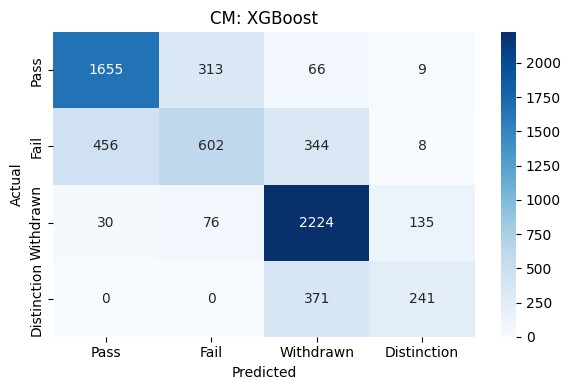

In [15]:
# =========================
# Cell 7: Tune XGBoost bằng Optuna trên validation và đánh giá trên test.
# XGBoost + Optuna (Tối ưu tham số)
# =========================
print('\n' + '='*60)
print('XGBOOST + OPTUNA')
print('='*60)

t0 = time.time()

# Optuna objective: tìm bộ tham số XGBoost tối ưu theo Macro-F1 trên validation.
def xgb_objective(trial):
    params = {
        # Số lượng cây boosting; lớn hơn thường học được mẫu phức tạp hơn nhưng tốn thời gian hơn.
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        # Độ sâu tối đa của từng cây; cao quá dễ overfit, thấp quá dễ underfit.
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        # Tốc độ học (shrinkage) mỗi vòng boosting; nhỏ hơn thường ổn định hơn.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        # Tỉ lệ lấy mẫu dòng train cho mỗi cây (stochastic boosting) để giảm overfit.
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        # Tỉ lệ lấy mẫu cột feature cho mỗi cây để tăng đa dạng giữa các cây.
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # Tổng trọng số tối thiểu trong một node con; giá trị lớn làm model bảo thủ hơn.
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        # Mức giảm loss tối thiểu để được phép split; lớn hơn => ít tách nhánh để regularize.
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        # L1 regularization trên leaf weights; khuyến khích độ thưa (sparsity).
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        # L2 regularization trên leaf weights; giúp trọng số mềm và ổn định hơn.
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # Multi-class: trả về xác suất cho tất cả lớp (không chỉ nhãn cứng).
        'objective': 'multi:softprob',
        # Số lớp mục tiêu trong bài toán.
        'num_class': NUM_CLASSES,
        # Metric nội bộ của XGBoost trong quá trình học (không phải metric chọn model cuối).
        'eval_metric': 'mlogloss',
        # Cố định seed để tái lập kết quả.
        'random_state': RANDOM_SEED,
        # Tắt log chi tiết để output gọn hơn.
        'verbosity': 0,
        # Dùng thuật toán histogram để train nhanh và tiết kiệm bộ nhớ.
        'tree_method': 'hist',
    }

    # Nếu có GPU, bật train trên CUDA để tăng tốc.
    if torch.cuda.is_available():
        params['device'] = 'cuda'

    model = XGBClassifier(**params)
    model.fit(X_tr, y_tr, verbose=False)
    pred = model.predict(X_val)
    return f1_score(y_val, pred, average='macro')

# Chạy tối ưu hóa tham số tự động; hướng maximize vì metric là Macro-F1.
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val Macro-F1: {study_xgb.best_value:.4f} ({time.time()-t0:.1f}s)')

# Lấy bộ tham số tốt nhất Optuna tìm được.
best_xgb_params = study_xgb.best_params
# Bổ sung các tham số cố định để train model cuối trên full train set.
best_xgb_params.update({
    'objective': 'multi:softprob',   # xuat xac suat da lop
    'num_class': NUM_CLASSES,        # so lop
    'eval_metric': 'mlogloss',       # metric noi bo cua XGB
    'random_state': RANDOM_SEED,     # seed tai lap
    'verbosity': 0,                  # tat log
    'tree_method': 'hist',           # train nhanh theo histogram
})
if torch.cuda.is_available():
    # Bật GPU cho model cuối nếu môi trường hỗ trợ.
    best_xgb_params['device'] = 'cuda'

best_xgb = XGBClassifier(**best_xgb_params)
best_xgb.fit(X_train, y_train, verbose=False)
result_xgb = evaluate_model('XGBoost', y_test, best_xgb.predict(X_test))


CATBOOST + OPTUNA
Best Val Macro-F1: 0.6543 (423.7s)

CatBoost
Accuracy:    0.7237
Macro-F1:    0.6517  << PRIMARY
Weighted-F1: 0.7096
              precision    recall  f1-score   support

        Pass       0.78      0.81      0.79      2043
        Fail       0.61      0.43      0.51      1410
   Withdrawn       0.74      0.90      0.81      2465
 Distinction       0.62      0.42      0.50       612

    accuracy                           0.72      6530
   macro avg       0.69      0.64      0.65      6530
weighted avg       0.71      0.72      0.71      6530



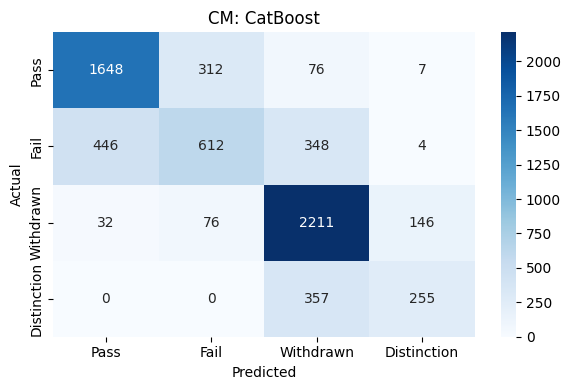

In [16]:
# =========================
# Cell 8: Tune CatBoost bằng Optuna, train model tốt nhất và báo cáo kết quả.
# CatBoost + Optuna (Tối ưu tham số)
# =========================
print('\n' + '='*60)
print('CATBOOST + OPTUNA')
print('='*60)

t0 = time.time()

# Optuna objective: tối ưu CatBoost theo Macro-F1 trên validation.
def cat_objective(trial):
    params = {
        # Số vòng boosting (số cây). Cao hơn thường mạnh hơn nhưng tốn thời gian hơn.
        'iterations': trial.suggest_int('iterations', 300, 1500),
        # Tốc độ học mỗi vòng; nhỏ hơn thường ổn định và ít overfit hơn.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        # Độ sâu cây đối xứng của CatBoost; sâu hơn bắt được mẫu phức tạp hơn.
        'depth': trial.suggest_int('depth', 3, 10),
        # L2 regularization trên leaf values; tăng lên để giảm overfit.
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        # Độ ngẫu nhiên khi chọn split score; cao hơn tăng regularization.
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
        # Mức độ bagging theo Bayesian bootstrap; >0 tăng đa dạng mẫu giữa các cây.
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        # Hàm mục tiêu đa lớp cho bài toán 4-class.
        'loss_function': 'MultiClass',
        # Seed cố định để tái lập kết quả.
        'random_seed': RANDOM_SEED,
        # Tắt log chi tiết để output ngắn gọn.
        'verbose': 0,
    }

    # Nếu có GPU, train CatBoost bằng GPU để tăng tốc.
    if torch.cuda.is_available():
        params['task_type'] = 'GPU'

    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val).astype(int).reshape(-1)
    return f1_score(y_val, pred, average='macro')

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(cat_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val Macro-F1: {study_cat.best_value:.4f} ({time.time()-t0:.1f}s)')

# Lấy bộ tham số tốt nhất mà Optuna tìm được.
best_cat_params = study_cat.best_params
# Bổ sung tham số cố định để train model cuối trên full train set.
best_cat_params.update({
    'loss_function': 'MultiClass',  # bai toan da lop
    'random_seed': RANDOM_SEED,     # seed tai lap
    'verbose': 0,                   # tat log
})
if torch.cuda.is_available():
    # Bật GPU cho model cuối nếu có hỗ trợ.
    best_cat_params['task_type'] = 'GPU'

best_cat = CatBoostClassifier(**best_cat_params)
best_cat.fit(X_train, y_train)
result_cat = evaluate_model('CatBoost', y_test, best_cat.predict(X_test).astype(int).reshape(-1))


TABULAR DL (MLP) + OPTUNA
Best Val Macro-F1: 0.6504 (1008.7s)

Tabular DL (MLP)
Accuracy:    0.7063
Macro-F1:    0.6490  << PRIMARY
Weighted-F1: 0.6989
              precision    recall  f1-score   support

        Pass       0.78      0.76      0.77      2043
        Fail       0.56      0.45      0.50      1410
   Withdrawn       0.75      0.85      0.80      2465
 Distinction       0.55      0.51      0.53       612

    accuracy                           0.71      6530
   macro avg       0.66      0.64      0.65      6530
weighted avg       0.70      0.71      0.70      6530



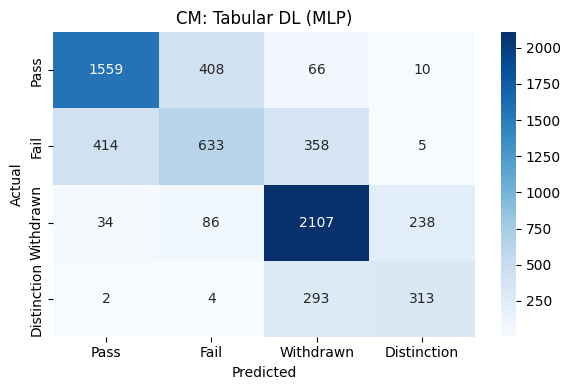

In [17]:
# =========================
# Cell 9: Tune Tabular MLP với Optuna, train lại cấu hình tốt nhất và đánh giá trên test.
# Tabular Deep Learning (PyTorch MLP) + Optuna (Tối ưu tham số)
# =========================
print('\n' + '='*60)
print('TABULAR DL (MLP) + OPTUNA')
print('='*60)

t0 = time.time()

# Optuna objective cho MLP tabular; trả về Macro-F1 để so sánh công bằng với các model khác.
def tabdl_objective(trial):
    params = {
        # Số neuron mỗi tầng ẩn; lớn hơn giúp học quan hệ phức tạp hơn nhưng dễ overfit hơn.
        'hidden_dim': trial.suggest_categorical('hidden_dim', [64, 128, 256, 512]),
        # Số tầng ẩn của MLP; nhiều tầng giúp biểu diễn sâu hơn.
        'num_layers': trial.suggest_int('num_layers', 1, 4),
        # Tỷ lệ dropout để regularization; cao hơn thường giảm overfit.
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        # Learning rate của optimizer; nhỏ hơn thường ổn định hơn.
        'lr': trial.suggest_float('lr', 1e-4, 5e-3, log=True),
        # L2 penalty (weight decay) để làm mượt trọng số.
        'weight_decay': trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True),
        # Kích thước mini-batch; ảnh hưởng tốc độ và độ ổn định gradient.
        'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256, 512]),
        # Số epoch train tối đa cho mỗi trial.
        'epochs': trial.suggest_int('epochs', 30, 120),
        # Early stopping: dừng nếu không cải thiện sau N epoch.
        'patience': 12,
    }
    _, best_f1 = train_tabdl_once(X_tr, y_tr, X_val, y_val, params, device=DEVICE)
    return best_f1

study_tabdl = optuna.create_study(direction='maximize')
study_tabdl.optimize(tabdl_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val Macro-F1: {study_tabdl.best_value:.4f} ({time.time()-t0:.1f}s)')

best_tabdl_params = study_tabdl.best_params.copy()
best_tabdl_params['patience'] = 15

# Train model cuối với một tập holdout tách từ train để early stopping.
X_full_tr, X_full_va, y_full_tr, y_full_va = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_train
)
best_tabdl, _ = train_tabdl_once(X_full_tr, y_full_tr, X_full_va, y_full_va, best_tabdl_params, device=DEVICE)

# Lấy xác suất trên test rồi đổi sang nhãn bằng argmax để đánh giá.
tabdl_prob_test = predict_proba_tabdl(best_tabdl, X_test, batch_size=1024, device=DEVICE)
result_tabdl = evaluate_model('Tabular DL (MLP)', y_test, np.argmax(tabdl_prob_test, axis=1))

STACKING (OOF) - XGB + CAT + TABDL
Fold 1/5 | train=20850 val=5213
Fold 2/5 | train=20850 val=5213
Fold 3/5 | train=20850 val=5213
Fold 4/5 | train=20851 val=5212
Fold 5/5 | train=20851 val=5212

Stacking (OOF + LogisticRegression)
Accuracy:    0.7265
Macro-F1:    0.6561  << PRIMARY
Weighted-F1: 0.7133
              precision    recall  f1-score   support

        Pass       0.77      0.82      0.79      2043
        Fail       0.60      0.44      0.51      1410
   Withdrawn       0.75      0.89      0.81      2465
 Distinction       0.63      0.43      0.51       612

    accuracy                           0.73      6530
   macro avg       0.69      0.64      0.66      6530
weighted avg       0.71      0.73      0.71      6530



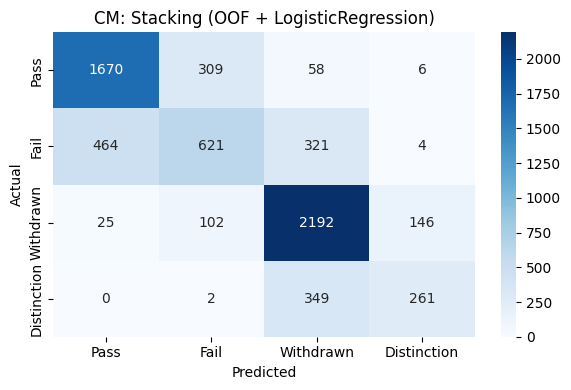

OOF stacking completed in 113.6s


In [18]:
# =========================
# Cell 10: Tạo OOF predictions từ base models để train meta-model và tránh leakage.
# Stacking Ensemble (OOF, chống leakage)
# =========================
print('STACKING (OOF) - XGB + CAT + TABDL')

t0 = time.time()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Xác suất OOF
n_train = len(y_train)
n_test = len(y_test)
# OOF predictions trên train cho từng base model; đây là đầu vào train cho meta-model.
oof_xgb = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)
oof_cat = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)
oof_tab = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)

test_xgb = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)
test_cat = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)
test_tab = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)

# Vòng lặp OOF: mỗi fold tạo dự đoán trên tập validation chưa gặp để tránh leakage.
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f'Fold {fold}/{N_FOLDS} | train={len(tr_idx)} val={len(va_idx)}')
    Xf_tr, yf_tr = X_train[tr_idx], y_train[tr_idx]
    Xf_va, yf_va = X_train[va_idx], y_train[va_idx]

    # Mô hình XGBoost
    m_xgb = XGBClassifier(**best_xgb_params)
    m_xgb.fit(Xf_tr, yf_tr, verbose=False)
    oof_xgb[va_idx] = m_xgb.predict_proba(Xf_va)
    test_xgb += m_xgb.predict_proba(X_test) / N_FOLDS

    # Mô hình CatBoost
    m_cat = CatBoostClassifier(**best_cat_params)
    m_cat.fit(Xf_tr, yf_tr)
    oof_cat[va_idx] = m_cat.predict_proba(Xf_va)
    test_cat += m_cat.predict_proba(X_test) / N_FOLDS

    # Mô hình Tabular DL
    m_tab, _ = train_tabdl_once(Xf_tr, yf_tr, Xf_va, yf_va, best_tabdl_params, device=DEVICE)
    oof_tab[va_idx] = predict_proba_tabdl(m_tab, Xf_va, batch_size=1024, device=DEVICE)
    test_tab += predict_proba_tabdl(m_tab, X_test, batch_size=1024, device=DEVICE) / N_FOLDS

# Meta feature: 3 model x 4 xác suất = 12 đặc trưng
meta_train = np.hstack([oof_xgb, oof_cat, oof_tab])
meta_test = np.hstack([test_xgb, test_cat, test_tab])

# Meta-model học cách kết hợp dự đoán base models; LR đa lớp giúp đơn giản và khó overfit.
meta_learner = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_SEED
)
meta_learner.fit(meta_train, y_train)

y_pred_stack = meta_learner.predict(meta_test)
result_stack = evaluate_model('Stacking (OOF + LogisticRegression)', y_test, y_pred_stack)
print(f'OOF stacking completed in {time.time() - t0:.1f}s')


Soft Voting (Equal: XGB+Cat+TabDL)
Accuracy:    0.7259
Macro-F1:    0.6567  << PRIMARY
Weighted-F1: 0.7132
              precision    recall  f1-score   support

        Pass       0.78      0.80      0.79      2043
        Fail       0.61      0.45      0.51      1410
   Withdrawn       0.74      0.90      0.81      2465
 Distinction       0.61      0.43      0.51       612

    accuracy                           0.73      6530
   macro avg       0.69      0.64      0.66      6530
weighted avg       0.71      0.73      0.71      6530



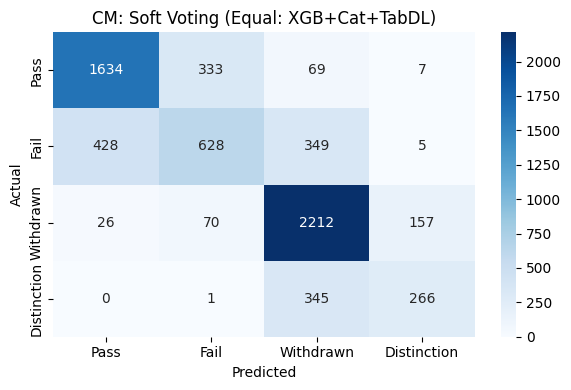


Ranking by Macro-F1:
                                  name  accuracy  macro_f1  weighted_f1
0   Soft Voting (Equal: XGB+Cat+TabDL)  0.725881  0.656694     0.713170
1  Stacking (OOF + LogisticRegression)  0.726493  0.656111     0.713275
2                             CatBoost  0.723737  0.651716     0.709585
3                     Tabular DL (MLP)  0.706279  0.648971     0.698896
4                              XGBoost  0.723124  0.646333     0.707696

Best model: Soft Voting (Equal: XGB+Cat+TabDL) | Macro-F1=0.6567


In [19]:
# =========================
# Cell 11: Baseline soft voting để so sánh nhanh với stacking.
# Tùy chọn: baseline soft voting
# =========================
prob_soft = (test_xgb + test_cat + test_tab) / 3
y_pred_soft = np.argmax(prob_soft, axis=1)
result_soft = evaluate_model('Soft Voting (Equal: XGB+Cat+TabDL)', y_test, y_pred_soft)

results = [result_xgb, result_cat, result_tabdl, result_stack, result_soft]
results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print('\nRanking by Macro-F1:')
print(results_df[['name', 'accuracy', 'macro_f1', 'weighted_f1']])

best_result = results_df.iloc[0].to_dict()
print(f"\nBest model: {best_result['name']} | Macro-F1={best_result['macro_f1']:.4f}")

In [20]:
# =========================
# Cell 12: Lưu tất cả model/optuna study và metadata để tái sử dụng khi deploy.
# Lưu models + metadata
# =========================
with open(os.path.join(SAVE_DIR, 'xgboost_best.pkl'), 'wb') as f:
    pickle.dump(best_xgb, f)
with open(os.path.join(SAVE_DIR, 'catboost_best.pkl'), 'wb') as f:
    pickle.dump(best_cat, f)

# Mô hình torch
torch.save(best_tabdl.state_dict(), os.path.join(SAVE_DIR, 'tabdl_best.pt'))
with open(os.path.join(SAVE_DIR, 'tabdl_arch.json'), 'w') as f:
    json.dump({
        'input_dim': int(X_train.shape[1]),
        'num_classes': NUM_CLASSES,
        **best_tabdl_params
    }, f, indent=2)

with open(os.path.join(SAVE_DIR, 'meta_learner.pkl'), 'wb') as f:
    pickle.dump(meta_learner, f)

with open(os.path.join(SAVE_DIR, 'optuna_xgb.pkl'), 'wb') as f:
    pickle.dump(study_xgb, f)
with open(os.path.join(SAVE_DIR, 'optuna_cat.pkl'), 'wb') as f:
    pickle.dump(study_cat, f)
with open(os.path.join(SAVE_DIR, 'optuna_tabdl.pkl'), 'wb') as f:
    pickle.dump(study_tabdl, f)

metadata = {
    'version': 'xgb_cat_tabdl_stacking_v1',
    'primary_metric': 'macro_f1',
    'n_features': len(feature_cols),
    'feature_cols': feature_cols,
    'models': ['XGBoost', 'CatBoost', 'TabularDL(MLP)'],
    'stacking': {
        'n_folds': N_FOLDS,
        'meta_learner': 'LogisticRegression',
        'meta_feature_dim': int(meta_train.shape[1]),
        'anti_leakage': 'OOF predictions via StratifiedKFold'
    },
    'results': results,
    'best': best_result,
    'best_params': {
        'xgb': study_xgb.best_params,
        'cat': study_cat.best_params,
        'tabdl': study_tabdl.best_params,
    }
}

with open(os.path.join(SAVE_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
# Lưu metadata để phục vụ tải model và dùng đúng feature/cấu hình khi suy luận.
with open(os.path.join(SAVE_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

print(f'Saved all artifacts to: {SAVE_DIR}')

Saved all artifacts to: ./saved_models_xgb_cat_tabdl_stacking


In [21]:
# =========================
# Cell 13: Nén thư mục kết quả thành file zip để tải xuống/backup.
# Nén thư mục output
# =========================
import shutil

# Đóng gói toàn bộ artifact thành 1 file zip để lưu trữ/chia sẻ.
zip_base = os.path.abspath(SAVE_DIR)
zip_path = shutil.make_archive(zip_base, 'zip', SAVE_DIR)
print(f'Created zip: {zip_path}')

Created zip: /content/saved_models_xgb_cat_tabdl_stacking.zip
